In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

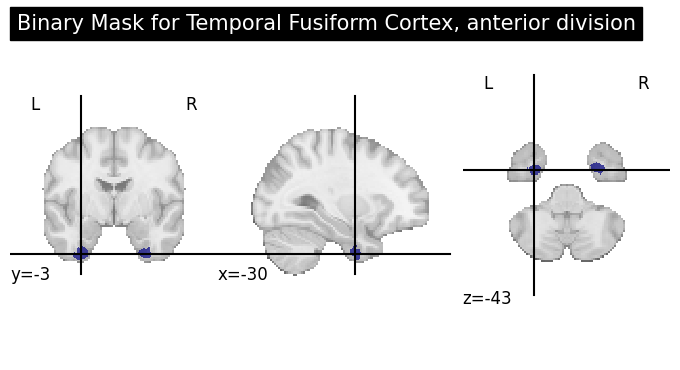

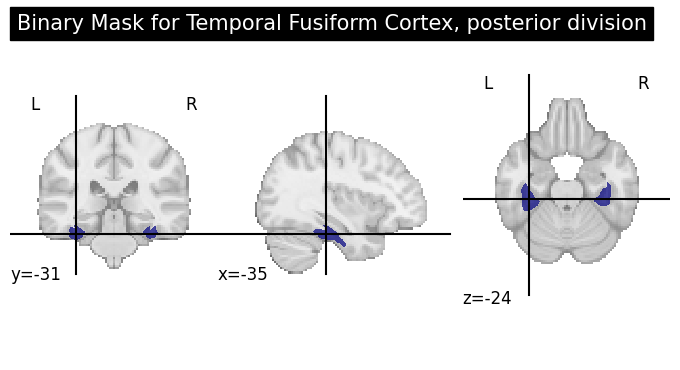

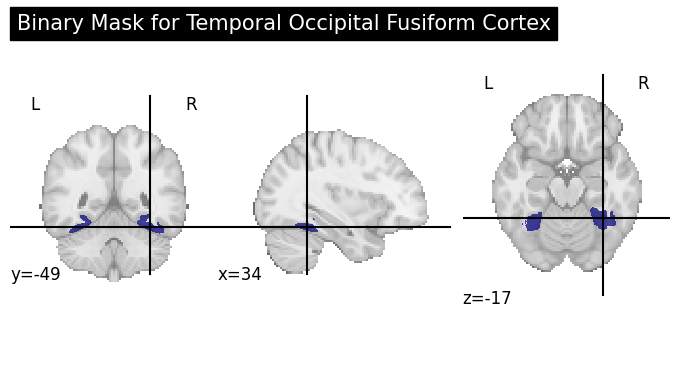

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Temporal Fusiform Cortex, anterior division"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis
# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Temporal Fusiform Cortex, posterior division"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name3 = "Temporal Occipital Fusiform Cortex"  # Region of Interest
region_idx3 = atlas_labels.index(region_name3)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask3 = math_img(f"img == {region_idx3}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask3, title=f"Binary Mask for {region_name3}", display_mode='ortho')
plotting.show()

## Loading a single ROI **(MEAN)**:- 1) Temporal Fusiform Cortex-Anterior Division
#### Then performing the experiments.

In [4]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
#print(control_mean_data1[79][2376])

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data1, non_dyslexic_mean_data1])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data1) + [0] * len(non_dyslexic_mean_data1))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(1547,)
(1547,)
(160, 1547)
(160,)


Training Accuracy on Temporal Fusiform Cortex- anterior division (Logistic Regression): 98.44%
Testing Accuracy on Temporal Fusiform Cortex- anterior division (Logistic Regression): 50.00%

Classification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Logistic Regression):
              precision    recall  f1-score   support

           0       0.50      0.44      0.47        16
           1       0.50      0.56      0.53        16

    accuracy                           0.50        32
   macro avg       0.50      0.50      0.50        32
weighted avg       0.50      0.50      0.50        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Logistic Regression): 0.50


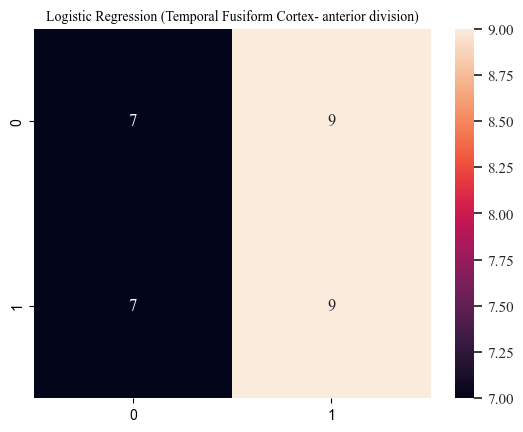

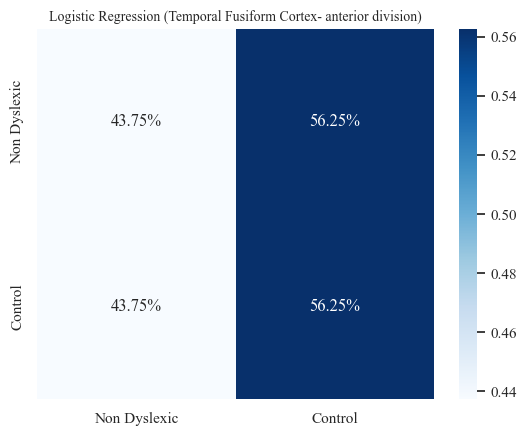

In [5]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (Logistic Regression): {log_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (Logistic Regression): {log_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Logistic Regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Logistic Regression): {log_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Logistic Regression (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(Log_Reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic Regression (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(Log_Reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- anterior division (Support Vector Machine): 64.06%
Testing Accuracy on Temporal Fusiform Cortex- anterior division (Support Vector Machine): 59.38%

Classification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.57      0.75      0.65        16
           1       0.64      0.44      0.52        16

    accuracy                           0.59        32
   macro avg       0.60      0.59      0.58        32
weighted avg       0.60      0.59      0.58        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Support Vector Machine): 0.59


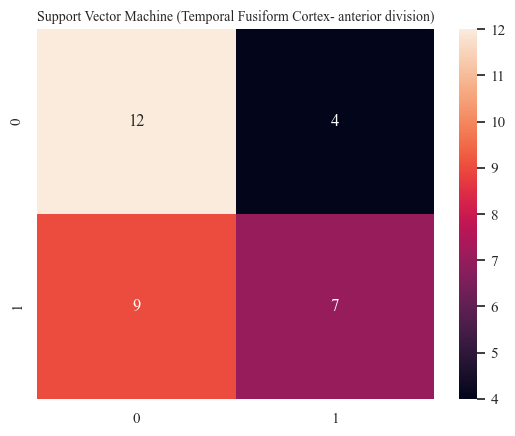

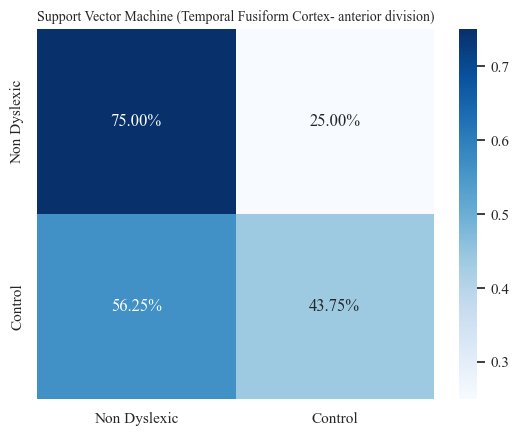

In [6]:
###### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Calculate training and testing accuracy
svm_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Support Vector Machine): {svm_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): 86.72%
Testing Accuracy on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): 43.75%

Classification Report for Testing Data on Temporal Fusiform Cortex- anterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.40      0.25      0.31        16
           1       0.45      0.62      0.53        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.42        32
weighted avg       0.43      0.44      0.42        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): 0.44


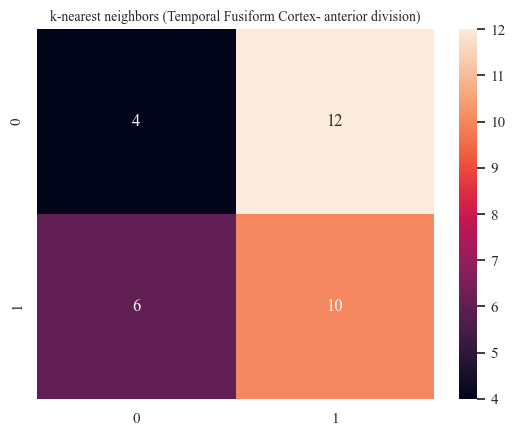

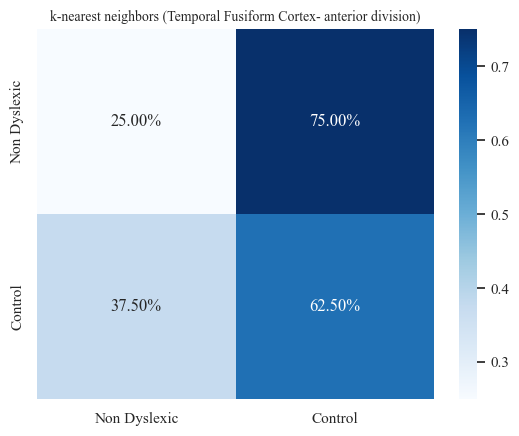

In [7]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (k-nearest neighbors): {knn_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 1547) Label:- (128,)
Total Testing set:-  Dataset:- (32, 1547) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         792,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 866,561 (3.31 MB)

 Trainable params: 866,561 (3.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5365 - loss: 0.7360 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7708 - loss: 0.4715
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9010 - loss: 0.3847
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9427 - loss: 0.3357
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9375 - loss: 0.2987
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8958 - loss: 0.2667
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9688 - loss: 0.2419
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9635 - loss: 0.2131
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9479 - loss: 0.1869
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9740 - loss: 0.1454
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9844 - loss: 0.1424
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9792 - loss: 0.1193


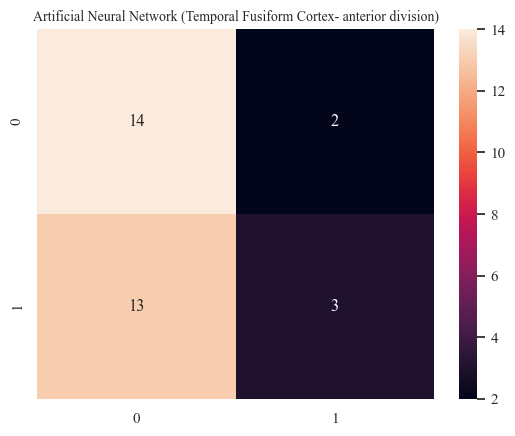

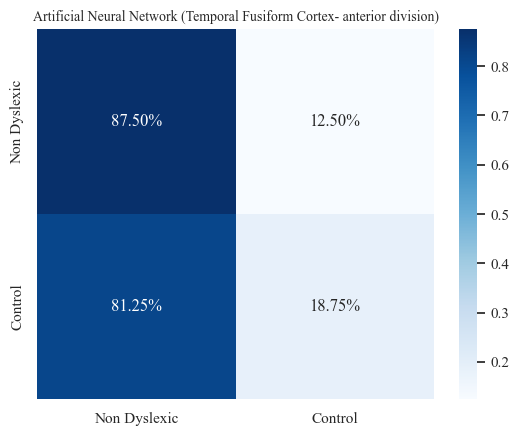

In [8]:
###### ANN Model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI1 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Artificial Neural Network): {ann_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- anterior division (Random Forest): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- anterior division (Random Forest): 65.62%

Classification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.73      0.50      0.59        16

    accuracy                           0.66        32
   macro avg       0.67      0.66      0.65        32
weighted avg       0.67      0.66      0.65        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Random Forest): 0.66


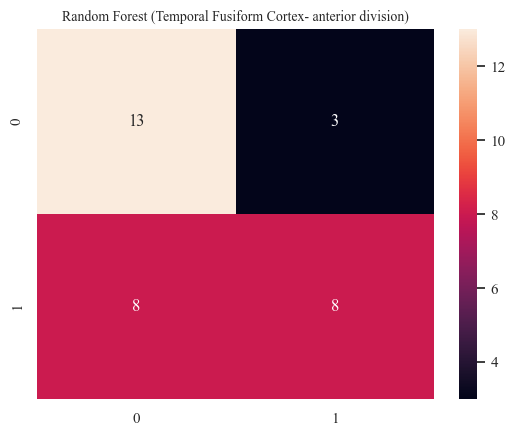

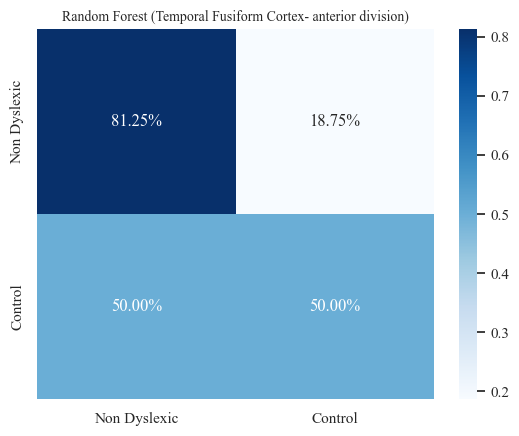

In [9]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (Random Forest): {rf_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (Random Forest): {rf_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (Random Forest): {rf_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('Random Forest (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- anterior division (XGBoost): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- anterior division (XGBoost): 68.75%

Classification Report for Testing Data on Temporal Fusiform Cortex- anterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.75      0.56      0.64        16

    accuracy                           0.69        32
   macro avg       0.70      0.69      0.68        32
weighted avg       0.70      0.69      0.68        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (XGBoost): 0.69


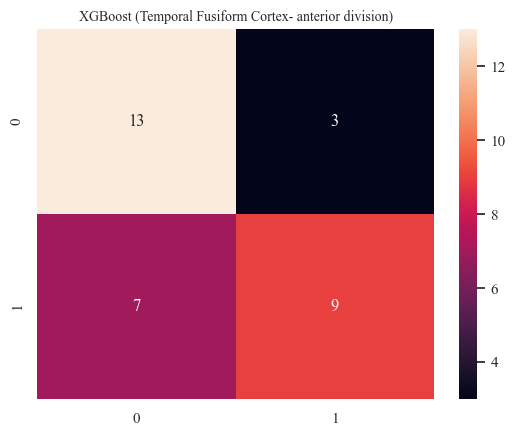

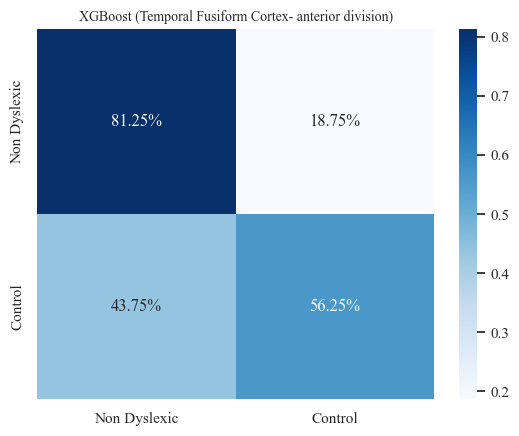

In [10]:
##### XGBoost model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI1 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI1 = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Temporal Fusiform Cortex- anterior division (XGBoost): {xgb_mean_train_accuracy_ROI1 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- anterior division (XGBoost): {xgb_mean_test_accuracy_ROI1 * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- anterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI1=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI1 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- anterior division (XGBoost): {xgb_mean_roc_ROI1:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
#print(cm)
plt.title('XGBoost (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Temporal Fusiform Cortex- anterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_1(XGBst)_percent.png", dpi=600)
plt.show()

In [11]:
mean1=[]
mean1.append([round(log_mean_prf_ROI1[0][0],2),round(log_mean_prf_ROI1[1][0],2),round(log_mean_prf_ROI1[2][0],2),round(log_mean_test_accuracy_ROI1,2),round(log_mean_roc_ROI1,2)])
mean1.append([round(log_mean_prf_ROI1[0][1],2),round(log_mean_prf_ROI1[1][1],2),round(log_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(svm_mean_prf_ROI1[0][0],2),round(svm_mean_prf_ROI1[1][0],2),round(svm_mean_prf_ROI1[2][0],2),round(svm_mean_test_accuracy_ROI1,2),round(svm_mean_roc_ROI1,2)])
mean1.append([round(svm_mean_prf_ROI1[0][1],2),round(svm_mean_prf_ROI1[1][1],2),round(svm_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(knn_mean_prf_ROI1[0][0],2),round(knn_mean_prf_ROI1[1][0],2),round(knn_mean_prf_ROI1[2][0],2),round(knn_mean_test_accuracy_ROI1,2),round(knn_mean_roc_ROI1,2)])
mean1.append([round(knn_mean_prf_ROI1[0][1],2),round(knn_mean_prf_ROI1[1][1],2),round(knn_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(ann_mean_prf_ROI1[0][0],2),round(ann_mean_prf_ROI1[1][0],2),round(ann_mean_prf_ROI1[2][0],2),round(ann_mean_test_accuracy_ROI1,2),round(ann_mean_roc_ROI1,2)])
mean1.append([round(ann_mean_prf_ROI1[0][1],2),round(ann_mean_prf_ROI1[1][1],2),round(ann_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(rf_mean_prf_ROI1[0][0],2),round(rf_mean_prf_ROI1[1][0],2),round(rf_mean_prf_ROI1[2][0],2),round(rf_mean_test_accuracy_ROI1,2),round(rf_mean_roc_ROI1,2)])
mean1.append([round(rf_mean_prf_ROI1[0][1],2),round(rf_mean_prf_ROI1[1][1],2),round(rf_mean_prf_ROI1[2][1],2),'',''])
mean1.append([round(xgb_mean_prf_ROI1[0][0],2),round(xgb_mean_prf_ROI1[1][0],2),round(xgb_mean_prf_ROI1[2][0],2),round(xgb_mean_test_accuracy_ROI1,2),round(xgb_mean_roc_ROI1,2)])
mean1.append([round(xgb_mean_prf_ROI1[0][1],2),round(xgb_mean_prf_ROI1[1][1],2),round(xgb_mean_prf_ROI1[2][1],2),'',''])

df1 = pd.DataFrame(mean1,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df=df.style.set_sticky(axis="index")
df1=df1.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
display(df1)
df1.to_excel('../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Table_Mean_ROI_1_Temporal_Fusiform_Cortex.xlsx', engine='openpyxl')


## Loading a single ROI **(MEAN)**:- 2. Temporal Fusiform Cortex-Posterior Division
#### Then performing the experiments.

In [12]:
####Loading the saved dataset in np format.
cmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data2, non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data2) + [0] * len(non_dyslexic_mean_data2))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(5553,)
(5553,)
(160, 5553)
(160,)


Training Accuracy on Temporal Fusiform Cortex- posterior division (Logistic regression): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- posterior division (Logistic regression): 40.62%

Classification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Logistic regression):
              precision    recall  f1-score   support

           0       0.33      0.19      0.24        16
           1       0.43      0.62      0.51        16

    accuracy                           0.41        32
   macro avg       0.38      0.41      0.38        32
weighted avg       0.38      0.41      0.38        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Logistic Regression): 0.41


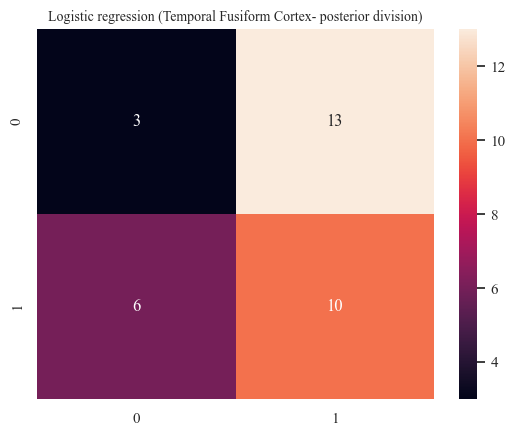

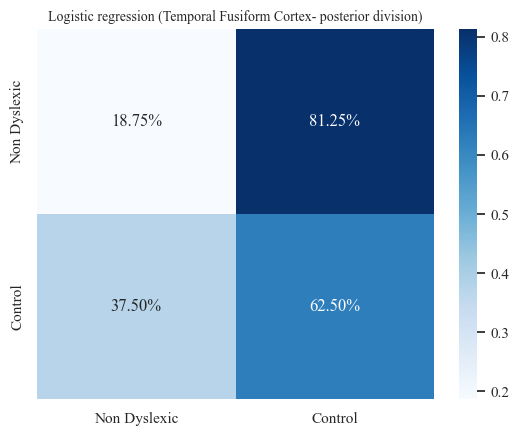

In [13]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (Logistic regression): {log_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (Logistic regression): {log_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Logistic Regression): {log_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- posterior division (Support Vector Machine): 72.66%
Testing Accuracy on Temporal Fusiform Cortex- posterior division (Support Vector Machine): 62.50%

Classification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.59      0.81      0.68        16
           1       0.70      0.44      0.54        16

    accuracy                           0.62        32
   macro avg       0.65      0.62      0.61        32
weighted avg       0.65      0.62      0.61        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Support Vector Machine): 0.62


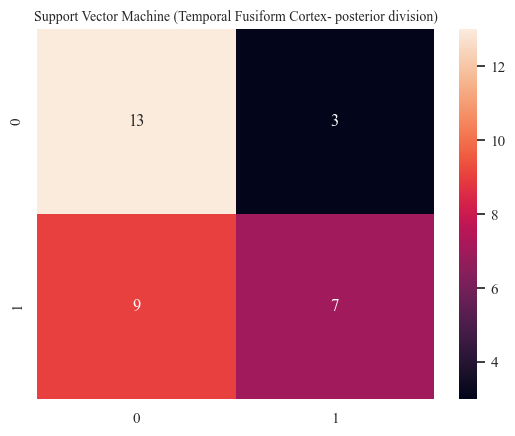

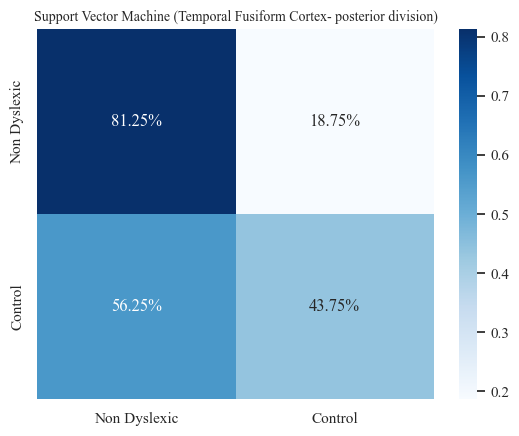

In [14]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (Support Vector Machine): {svm_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (Support Vector Machine): {svm_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Support Vector Machine): {svm_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): 54.69%
Testing Accuracy on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): 56.25%

Classification Report for Testing Data on Temporal Fusiform Cortex- posterior division (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.75      0.19      0.30        16
           1       0.54      0.94      0.68        16

    accuracy                           0.56        32
   macro avg       0.64      0.56      0.49        32
weighted avg       0.64      0.56      0.49        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): 0.56


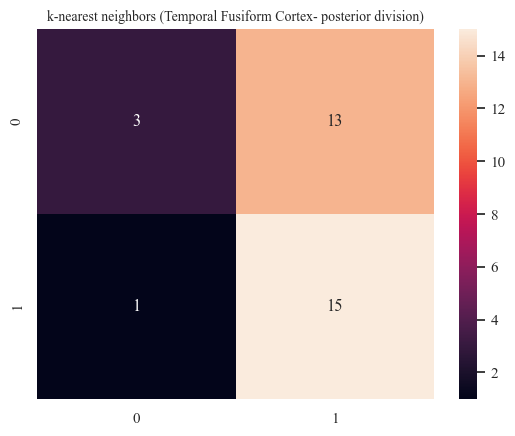

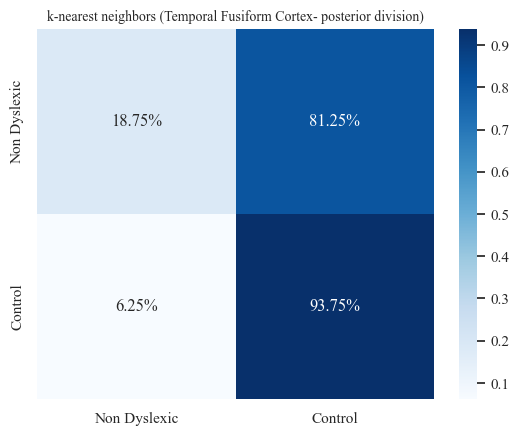

In [15]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): {knn_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): {knn_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (k-nearest neighbors): {knn_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 5553) Label:- (128,)
Total Testing set:-  Dataset:- (32, 5553) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 512)                 │       2,843,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,917,633 (11.13 MB)

 Trainable params: 2,917,633 (11.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4688 - loss: 0.7385 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8750 - loss: 0.3554
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9896 - loss: 0.2770
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9896 - loss: 0.2043
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.1149
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0748
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0334
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0165
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0064
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0030
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 9.3346e

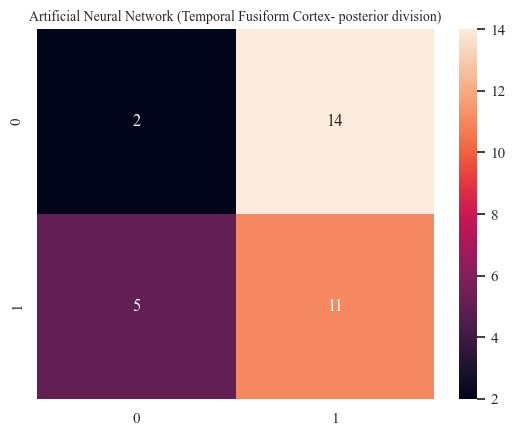

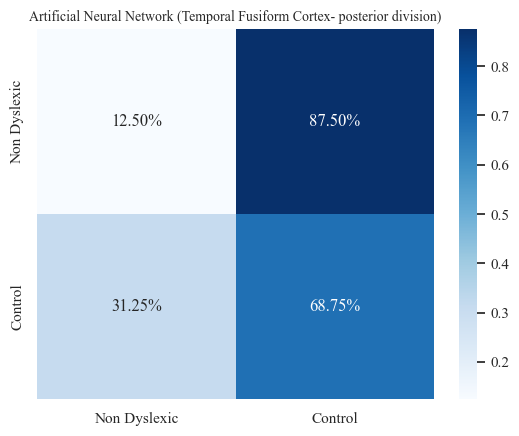

In [16]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (Artificial Neural Network): {ann_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (Artificial Neural Network): {ann_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Artificial Neural Network): {ann_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- posterior division (Random Forest): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- posterior division (Random Forest): 65.62%

Classification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Random Forest):
              precision    recall  f1-score   support

           0       0.61      0.88      0.72        16
           1       0.78      0.44      0.56        16

    accuracy                           0.66        32
   macro avg       0.69      0.66      0.64        32
weighted avg       0.69      0.66      0.64        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Random Forest): 0.66


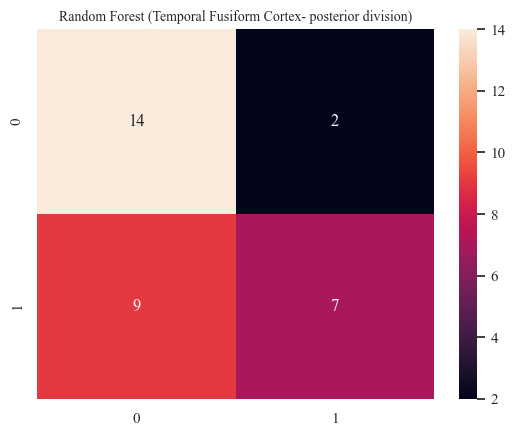

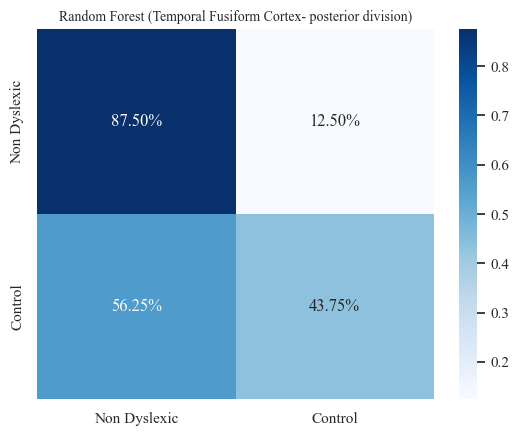

In [17]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (Random Forest): {rf_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (Random Forest): {rf_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (Random Forest): {rf_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- posterior division (XGBoost): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- posterior division (XGBoost): 43.75%

Classification Report for Testing Data on Temporal Fusiform Cortex- posterior division (XGBoost):
              precision    recall  f1-score   support

           0       0.42      0.31      0.36        16
           1       0.45      0.56      0.50        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.43        32
weighted avg       0.43      0.44      0.43        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (XGBoost): 0.44


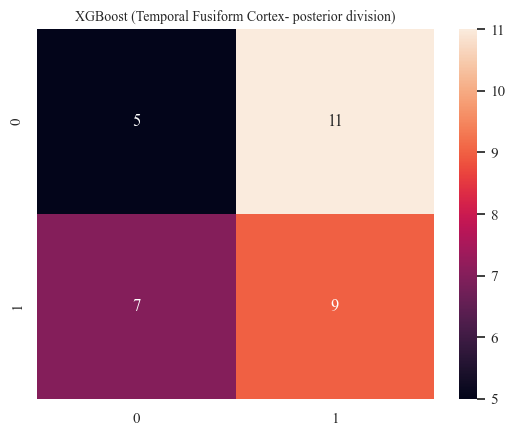

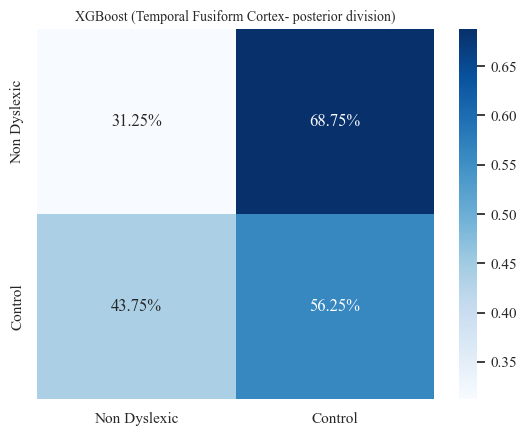

In [18]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- posterior division (XGBoost): {xgb_mean_train_accuracy_ROI2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- posterior division (XGBoost): {xgb_mean_test_accuracy_ROI2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- posterior division (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- posterior division (XGBoost): {xgb_mean_roc_ROI2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Temporal Fusiform Cortex- posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_2(XGBst)_percent.png", dpi=600)
plt.show()

In [19]:
mean2=[]
mean2.append([round(log_mean_prf_ROI2[0][0],2),round(log_mean_prf_ROI2[1][0],2),round(log_mean_prf_ROI2[2][0],2),round(log_mean_test_accuracy_ROI2,2),round(log_mean_roc_ROI2,2)])
mean2.append([round(log_mean_prf_ROI2[0][1],2),round(log_mean_prf_ROI2[1][1],2),round(log_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(svm_mean_prf_ROI2[0][0],2),round(svm_mean_prf_ROI2[1][0],2),round(svm_mean_prf_ROI2[2][0],2),round(svm_mean_test_accuracy_ROI2,2),round(svm_mean_roc_ROI2,2)])
mean2.append([round(svm_mean_prf_ROI2[0][1],2),round(svm_mean_prf_ROI2[1][1],2),round(svm_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(knn_mean_prf_ROI2[0][0],2),round(knn_mean_prf_ROI2[1][0],2),round(knn_mean_prf_ROI2[2][0],2),round(knn_mean_test_accuracy_ROI2,2),round(knn_mean_roc_ROI2,2)])
mean2.append([round(knn_mean_prf_ROI2[0][1],2),round(knn_mean_prf_ROI2[1][1],2),round(knn_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(ann_mean_prf_ROI2[0][0],2),round(ann_mean_prf_ROI2[1][0],2),round(ann_mean_prf_ROI2[2][0],2),round(ann_mean_test_accuracy_ROI2,2),round(ann_mean_roc_ROI2,2)])
mean2.append([round(ann_mean_prf_ROI2[0][1],2),round(ann_mean_prf_ROI2[1][1],2),round(ann_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(rf_mean_prf_ROI2[0][0],2),round(rf_mean_prf_ROI2[1][0],2),round(rf_mean_prf_ROI2[2][0],2),round(rf_mean_test_accuracy_ROI2,2),round(rf_mean_roc_ROI2,2)])
mean2.append([round(rf_mean_prf_ROI2[0][1],2),round(rf_mean_prf_ROI2[1][1],2),round(rf_mean_prf_ROI2[2][1],2),'',''])
mean2.append([round(xgb_mean_prf_ROI2[0][0],2),round(xgb_mean_prf_ROI2[1][0],2),round(xgb_mean_prf_ROI2[2][0],2),round(xgb_mean_test_accuracy_ROI2,2),round(xgb_mean_roc_ROI2,2)])
mean2.append([round(xgb_mean_prf_ROI2[0][1],2),round(xgb_mean_prf_ROI2[1][1],2),round(xgb_mean_prf_ROI2[2][1],2),'',''])

df2 = pd.DataFrame(mean2,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_2 (Mean) Temporal Fusiform Cortex- posterior division")
display(df2)
df2.to_excel('../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Table_Mean_ROI_2_Temporal_Fusiform_Cortex.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.33    0.19      0.24     0.41   
                           Control            0.43    0.62      0.51            
Support Vector Machine     Non-Dyslexic       0.59    0.81      0.68     0.62   
                           Control            0.70    0.44      0.54            
k-nearest neighbors        Non-Dyslexic       0.75    0.19      0.30     0.56   
                           Control            0.54    0.94      0.68            
Artificial Neural Networks Non-Dyslexic       0.29    0.12      0.17     0.41   
                           Control            0.44    0.69      0.54            
Random Forest              Non-Dyslexic       0.61    0.88      0.72     0.66   
                           Control            0.78    0.44      0.56            
XGBoost                    Non-Dyslexic       0.42    0.31      0.36     0.44   
                           Control            0.45    0.56      0.50            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.41  
                           Control               
Support Vector Machine     Non-Dyslexic    0.62  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.56  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.41  
                           Control               
Random Forest              Non-Dyslexic    0.66  
                           Control               
XGBoost                    Non-Dyslexic    0.44  
                           Control

## Loading a single ROI **(MEAN)**:- 3. Temporal Occipital Fusiform Cortex
#### Then performing the experiments.

In [20]:
####Loading the saved dataset in np format.
cmd3 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data3, non_dyslexic_mean_data3])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data3) + [0] * len(non_dyslexic_mean_data3))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(5066,)
(5066,)
(160, 5066)
(160,)


Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Logistic regression): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Logistic regression): 65.62%

Classification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Logistic regression):
              precision    recall  f1-score   support

           0       0.69      0.56      0.62        16
           1       0.63      0.75      0.69        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.65        32
weighted avg       0.66      0.66      0.65        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Logistic Regression): 0.66


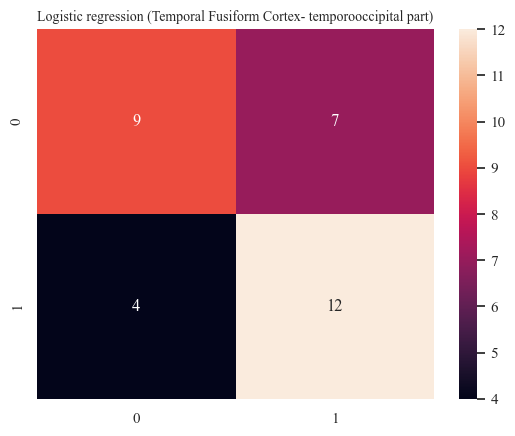

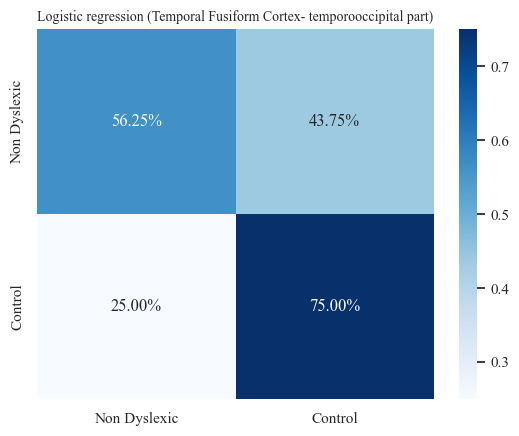

In [21]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Logistic regression): {log_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Logistic regression): {log_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Logistic Regression): {log_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): 71.09%
Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): 62.50%

Classification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.59      0.81      0.68        16
           1       0.70      0.44      0.54        16

    accuracy                           0.62        32
   macro avg       0.65      0.62      0.61        32
weighted avg       0.65      0.62      0.61        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): 0.62


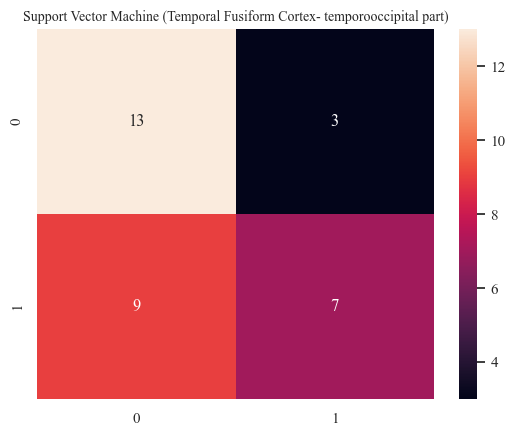

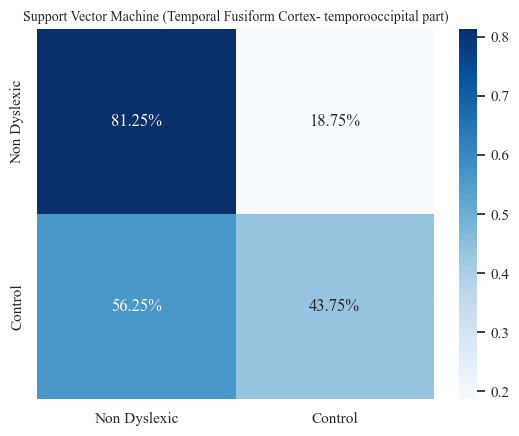

In [22]:
##### SVM model

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): {svm_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): {svm_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Support Vector Machine): {svm_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): 56.25%
Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): 62.50%

Classification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.58      0.88      0.70        16
           1       0.75      0.38      0.50        16

    accuracy                           0.62        32
   macro avg       0.67      0.62      0.60        32
weighted avg       0.67      0.62      0.60        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): 0.62


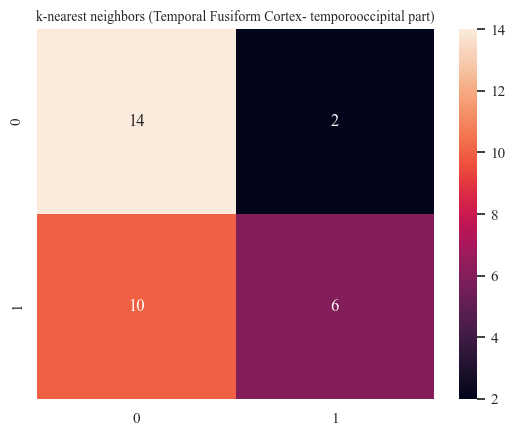

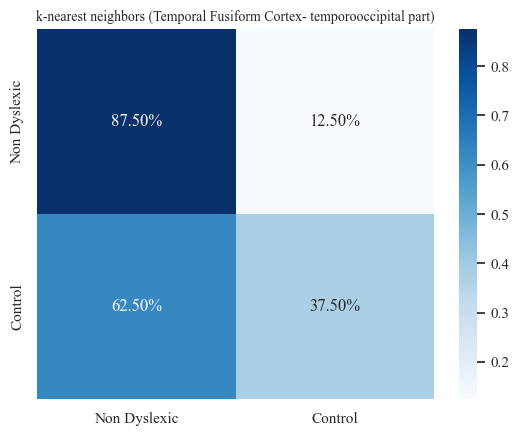

In [23]:
##### KNN model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): {knn_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): {knn_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (k-nearest neighbors): {knn_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(KNN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 5066) Label:- (128,)
Total Testing set:-  Dataset:- (32, 5066) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 512)                 │       2,594,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,668,289 (10.18 MB)

 Trainable params: 2,668,289 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5052 - loss: 0.7720 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9427 - loss: 0.3494
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9896 - loss: 0.2957
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9896 - loss: 0.2108
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9896 - loss: 0.1454
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9948 - loss: 0.0861
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0651
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9896 - loss: 0.0396
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9896 - loss: 0.0245
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0130
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0119
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0085


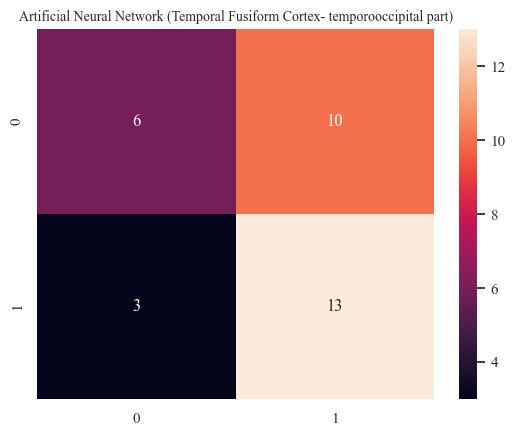

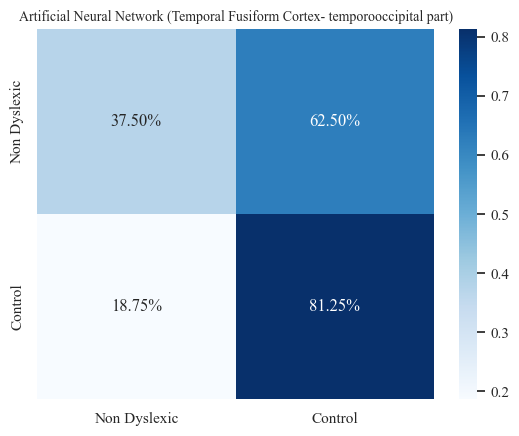

In [24]:
###### ANN Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
ann_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Artificial Neural Network): {ann_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Artificial Neural Network): {ann_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))
ann_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Artificial Neural Network): {ann_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Random Forest): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Random Forest): 62.50%

Classification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Random Forest):
              precision    recall  f1-score   support

           0       0.64      0.56      0.60        16
           1       0.61      0.69      0.65        16

    accuracy                           0.62        32
   macro avg       0.63      0.62      0.62        32
weighted avg       0.63      0.62      0.62        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Random Forest): 0.62


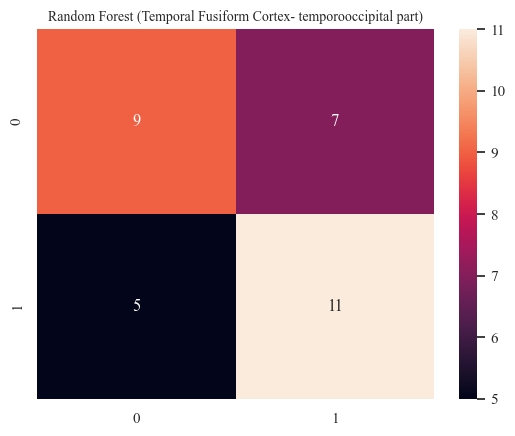

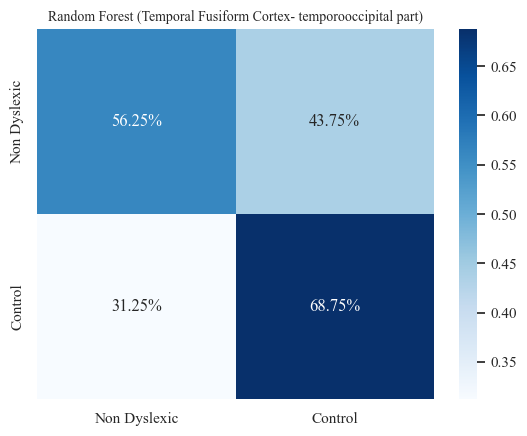

In [25]:
##### Random Forest model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (Random Forest): {rf_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (Random Forest): {rf_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (Random Forest): {rf_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(Rand_Forst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(Rand_Forst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (XGBoost): 50.00%

Classification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        16
           1       0.50      0.62      0.56        16

    accuracy                           0.50        32
   macro avg       0.50      0.50      0.49        32
weighted avg       0.50      0.50      0.49        32


ROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (XGBoost): 0.50


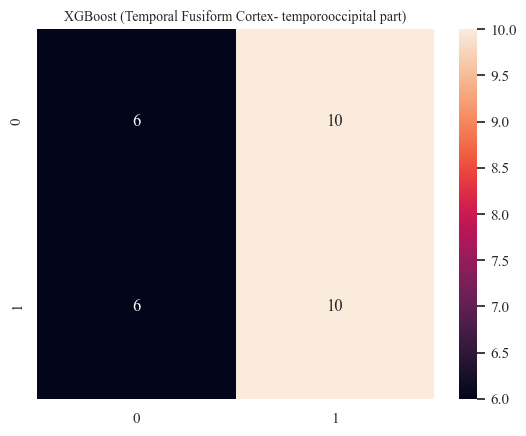

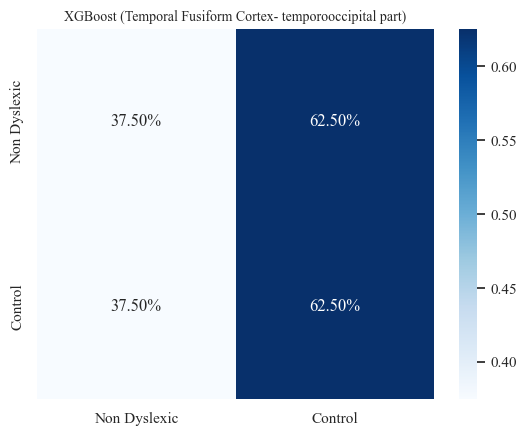

In [26]:
##### XGBoost (Extreme Gradient Boosting) model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROI3 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROI3 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex- temporooccipital part (XGBoost): {xgb_mean_train_accuracy_ROI3 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex- temporooccipital part (XGBoost): {xgb_mean_test_accuracy_ROI3 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex- temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROI3=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROI3 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex- temporooccipital part (XGBoost): {xgb_mean_roc_ROI3:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(XGBoost)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Temporal Fusiform Cortex- temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROI_3(XGBoost)_percent.png", dpi=600)
plt.show()

In [27]:
mean3=[]
mean3.append([round(log_mean_prf_ROI3[0][0],2),round(log_mean_prf_ROI3[1][0],2),round(log_mean_prf_ROI3[2][0],2),round(log_mean_test_accuracy_ROI3,2),round(log_mean_roc_ROI3,2)])
mean3.append([round(log_mean_prf_ROI3[0][1],2),round(log_mean_prf_ROI3[1][1],2),round(log_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(svm_mean_prf_ROI3[0][0],2),round(svm_mean_prf_ROI3[1][0],2),round(svm_mean_prf_ROI3[2][0],2),round(svm_mean_test_accuracy_ROI3,2),round(svm_mean_roc_ROI3,2)])
mean3.append([round(svm_mean_prf_ROI3[0][1],2),round(svm_mean_prf_ROI3[1][1],2),round(svm_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(knn_mean_prf_ROI3[0][0],2),round(knn_mean_prf_ROI3[1][0],2),round(knn_mean_prf_ROI3[2][0],2),round(knn_mean_test_accuracy_ROI3,2),round(knn_mean_roc_ROI3,2)])
mean3.append([round(knn_mean_prf_ROI3[0][1],2),round(knn_mean_prf_ROI3[1][1],2),round(knn_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(ann_mean_prf_ROI3[0][0],2),round(ann_mean_prf_ROI3[1][0],2),round(ann_mean_prf_ROI3[2][0],2),round(ann_mean_test_accuracy_ROI3,2),round(ann_mean_roc_ROI3,2)])
mean3.append([round(ann_mean_prf_ROI3[0][1],2),round(ann_mean_prf_ROI3[1][1],2),round(ann_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(rf_mean_prf_ROI3[0][0],2),round(rf_mean_prf_ROI3[1][0],2),round(rf_mean_prf_ROI3[2][0],2),round(rf_mean_test_accuracy_ROI3,2),round(rf_mean_roc_ROI3,2)])
mean3.append([round(rf_mean_prf_ROI3[0][1],2),round(rf_mean_prf_ROI3[1][1],2),round(rf_mean_prf_ROI3[2][1],2),'',''])
mean3.append([round(xgb_mean_prf_ROI3[0][0],2),round(xgb_mean_prf_ROI3[1][0],2),round(xgb_mean_prf_ROI3[2][0],2),round(xgb_mean_test_accuracy_ROI3,2),round(xgb_mean_roc_ROI3,2)])
mean3.append([round(xgb_mean_prf_ROI3[0][1],2),round(xgb_mean_prf_ROI3[1][1],2),round(xgb_mean_prf_ROI3[2][1],2),'',''])

df2 = pd.DataFrame(mean3,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
#df2=df2.style.set_sticky(axis="index")
df2.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
df2.style.set_caption("Table ROI_3 (Mean) Temporal Fusiform Cortex- temporooccipital part")
display(df2)
df2.to_excel('../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Table_Mean_ROI_3_Temporal_Fusiform_Cortex.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.69    0.56      0.62     0.66   
                           Control            0.63    0.75      0.69            
Support Vector Machine     Non-Dyslexic       0.59    0.81      0.68     0.62   
                           Control            0.70    0.44      0.54            
k-nearest neighbors        Non-Dyslexic       0.58    0.88      0.70     0.62   
                           Control            0.75    0.38      0.50            
Artificial Neural Networks Non-Dyslexic       0.67    0.38      0.48     0.59   
                           Control            0.57    0.81      0.67            
Random Forest              Non-Dyslexic       0.64    0.56      0.60     0.62   
                           Control            0.61    0.69      0.65            
XGBoost                    Non-Dyslexic       0.50    0.38      0.43      0.5   
                           Control            0.50    0.62      0.56            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.66  
                           Control               
Support Vector Machine     Non-Dyslexic    0.62  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.62  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.59  
                           Control               
Random Forest              Non-Dyslexic    0.62  
                           Control               
XGBoost                    Non-Dyslexic     0.5  
                           Control

## Combining ROIs  1 and 2 **(MEAN)**:- Temporal Fusiform Cortex- 1) Anterior division & 2) Posterior division 
#### Combining them into a single dataset to perform the experiments.

In [28]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

80
80
80
80
(1547,)
(1547,)
(5553,)
(5553,)

(5553,)
(5553,)
(5553,)
(5553,)


In [29]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2 ,non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine_1_2.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(320, 5553)
(320,)


Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression): 98.83%
Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression): 57.81%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression):
              precision    recall  f1-score   support

           0       0.56      0.69      0.62        32
           1       0.60      0.47      0.53        32

    accuracy                           0.58        64
   macro avg       0.58      0.58      0.57        64
weighted avg       0.58      0.58      0.57        64


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Logistic Regression): 0.58


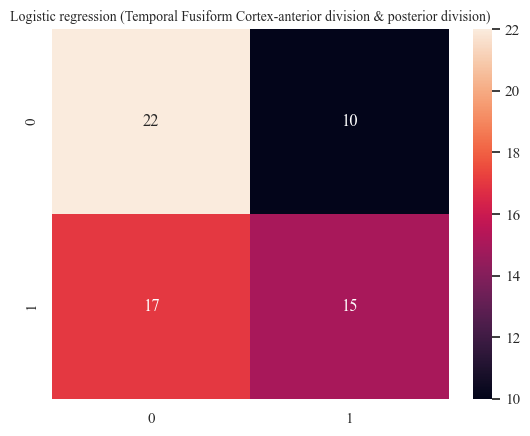

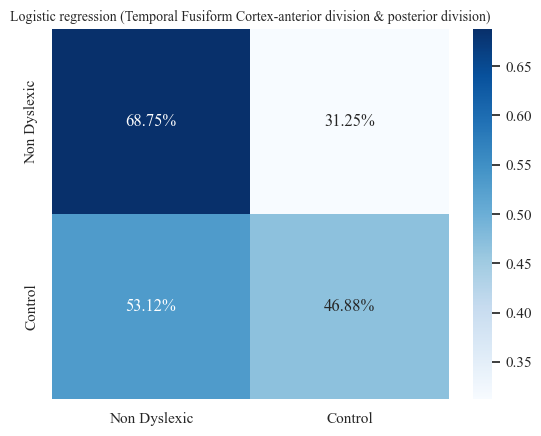

In [30]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression): {log_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression): {log_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Logistic Regression): {log_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): 64.06%
Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): 50.00%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine):
              precision    recall  f1-score   support

           0       0.50      0.84      0.63        32
           1       0.50      0.16      0.24        32

    accuracy                           0.50        64
   macro avg       0.50      0.50      0.43        64
weighted avg       0.50      0.50      0.43        64


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): 0.50


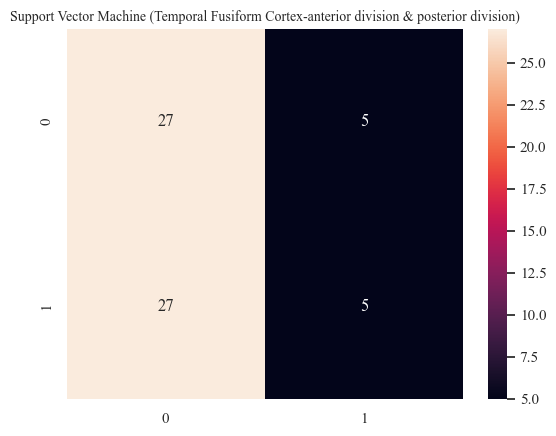

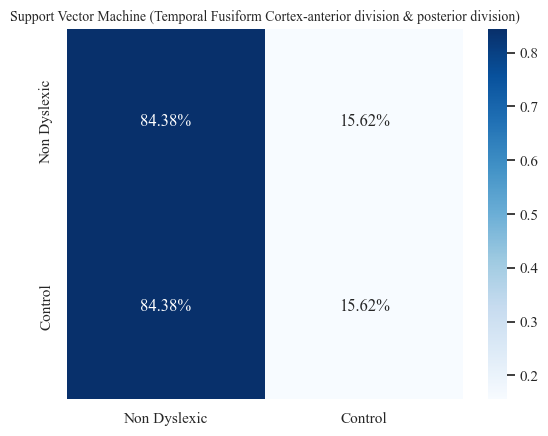

In [31]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): {svm_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): {svm_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Support Vector Machine): {svm_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): 62.89%
Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): 43.75%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.46      0.75      0.57        32
           1       0.33      0.12      0.18        32

    accuracy                           0.44        64
   macro avg       0.40      0.44      0.38        64
weighted avg       0.40      0.44      0.38        64


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): 0.44


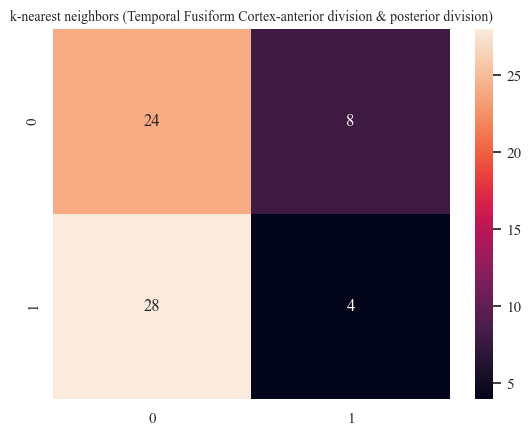

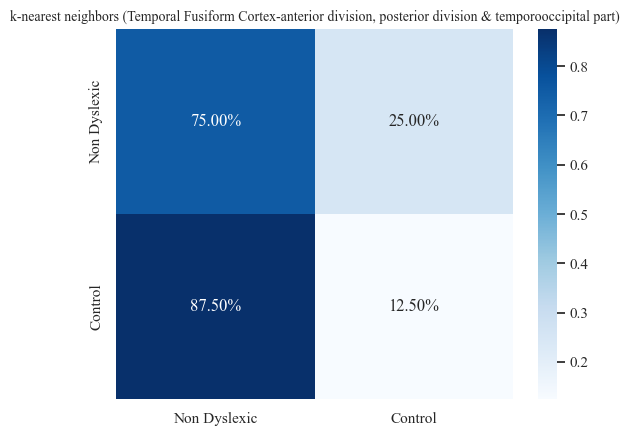

In [32]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): {knn_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): {knn_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(k-nearest neighbors): {knn_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(KNN)_percent.png", dpi=600)
plt.show()

In [33]:
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (320, 5553)
Total Labels:-  (320,)
Total Training set:-  Dataset:- (256, 5553) Label:- (256,)
Total Testing set:-  Dataset:- (64, 5553) Label:- (64,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 512)                 │       2,843,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,919,681 (11.14 MB)

 Trainable params: 2,919,681 (11.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4906 - loss: 0.7000  
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7875 - loss: 0.4653
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8161 - loss: 0.4250
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8495 - loss: 0.3528
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8938 - loss: 0.2745
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8859 - loss: 0.2346
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9266 - loss: 0.1832
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8859 - loss: 0.2388
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9026 - loss: 0.1840
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9161 - loss: 0.1543
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9187 - loss: 0.1361
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9344 - loss: 0.1070

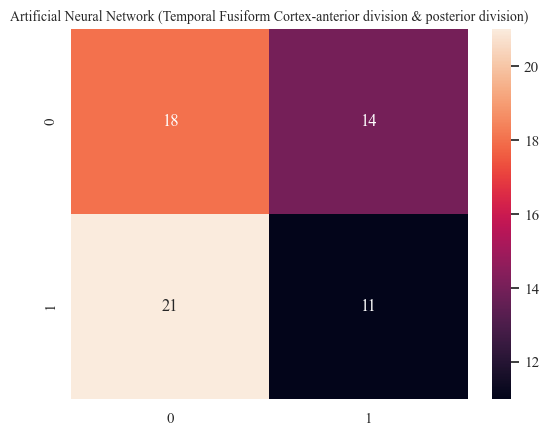

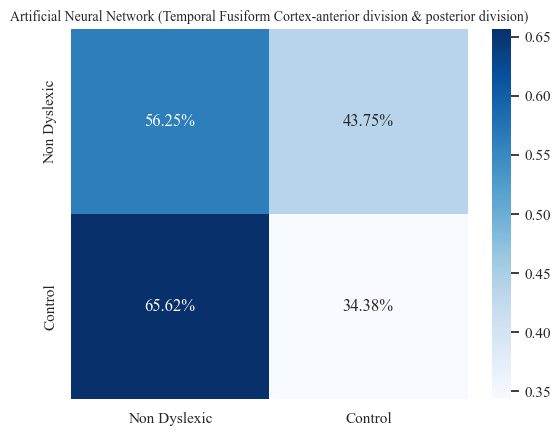

In [34]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Artificial Neural Network): {ann_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Artificial Neural Network): {ann_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Artificial Neural Network): {ann_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): 100.00%
Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): 60.94%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest):
              precision    recall  f1-score   support

           0       0.60      0.66      0.63        32
           1       0.62      0.56      0.59        32

    accuracy                           0.61        64
   macro avg       0.61      0.61      0.61        64
weighted avg       0.61      0.61      0.61        64


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): 0.61


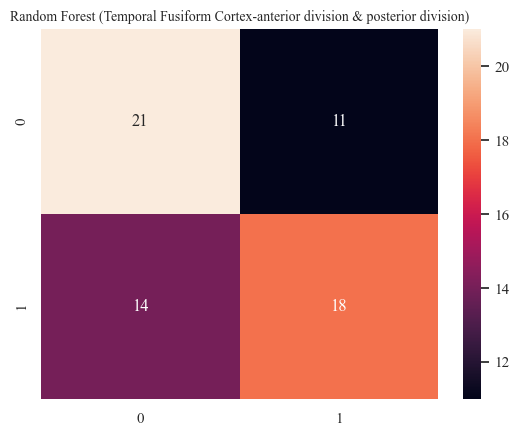

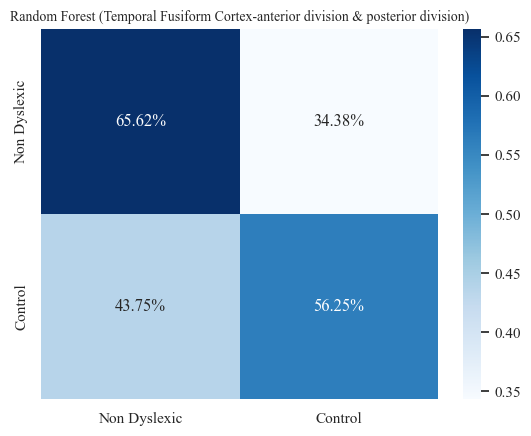

In [35]:
#Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): {rf_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): {rf_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(Random Forest): {rf_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): 100.00%
Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): 54.69%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost):
              precision    recall  f1-score   support

           0       0.54      0.59      0.57        32
           1       0.55      0.50      0.52        32

    accuracy                           0.55        64
   macro avg       0.55      0.55      0.55        64
weighted avg       0.55      0.55      0.55        64


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): 0.55


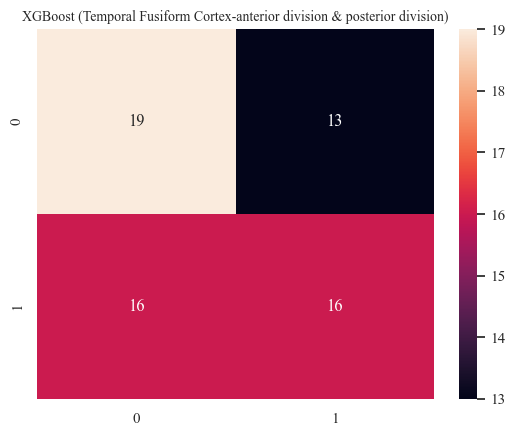

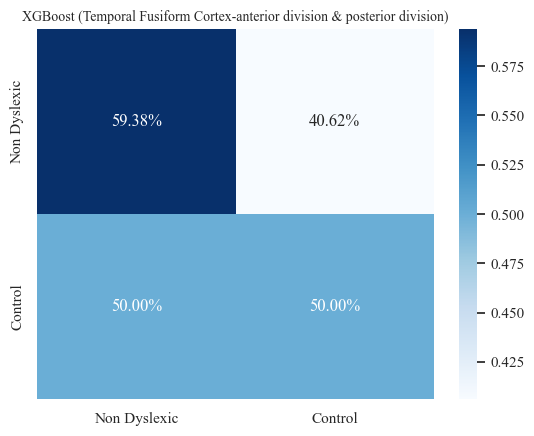

In [36]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_ROIs_1_2 = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_ROIs_1_2 = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): {xgb_mean_train_accuracy_ROIs_1_2 * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): {xgb_mean_test_accuracy_ROIs_1_2 * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_ROIs_1_2=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_ROIs_1_2 = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division & posterior division(XGBoost): {xgb_mean_roc_ROIs_1_2:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(XGBoost)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Temporal Fusiform Cortex-anterior division & posterior division)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_ROIs_1_2(XGBoost)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [37]:
mean_all=[]
mean_all.append([round(log_mean_prf_ROIs_1_2[0][0],2),round(log_mean_prf_ROIs_1_2[1][0],2),round(log_mean_prf_ROIs_1_2[2][0],2),round(log_mean_test_accuracy_ROIs_1_2,2),round(log_mean_roc_ROIs_1_2,2)])
mean_all.append([round(log_mean_prf_ROIs_1_2[0][1],2),round(log_mean_prf_ROIs_1_2[1][1],2),round(log_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_ROIs_1_2[0][0],2),round(svm_mean_prf_ROIs_1_2[1][0],2),round(svm_mean_prf_ROIs_1_2[2][0],2),round(svm_mean_test_accuracy_ROIs_1_2,2),round(svm_mean_roc_ROIs_1_2,2)])
mean_all.append([round(svm_mean_prf_ROIs_1_2[0][1],2),round(svm_mean_prf_ROIs_1_2[1][1],2),round(svm_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_ROIs_1_2[0][0],2),round(knn_mean_prf_ROIs_1_2[1][0],2),round(knn_mean_prf_ROIs_1_2[2][0],2),round(knn_mean_test_accuracy_ROIs_1_2,2),round(knn_mean_roc_ROIs_1_2,2)])
mean_all.append([round(knn_mean_prf_ROIs_1_2[0][1],2),round(knn_mean_prf_ROIs_1_2[1][1],2),round(knn_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_ROIs_1_2[0][0],2),round(ann_mean_prf_ROIs_1_2[1][0],2),round(ann_mean_prf_ROIs_1_2[2][0],2),round(ann_mean_test_accuracy_ROIs_1_2,2),round(ann_mean_roc_ROIs_1_2,2)])
mean_all.append([round(ann_mean_prf_ROIs_1_2[0][1],2),round(ann_mean_prf_ROIs_1_2[1][1],2),round(ann_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_ROIs_1_2[0][0],2),round(rf_mean_prf_ROIs_1_2[1][0],2),round(rf_mean_prf_ROIs_1_2[2][0],2),round(rf_mean_test_accuracy_ROIs_1_2,2),round(rf_mean_roc_ROIs_1_2,2)])
mean_all.append([round(rf_mean_prf_ROIs_1_2[0][1],2),round(rf_mean_prf_ROIs_1_2[1][1],2),round(rf_mean_prf_ROIs_1_2[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_ROIs_1_2[0][0],2),round(xgb_mean_prf_ROIs_1_2[1][0],2),round(xgb_mean_prf_ROIs_1_2[2][0],2),round(xgb_mean_test_accuracy_ROIs_1_2,2),round(xgb_mean_roc_ROIs_1_2,2)])
mean_all.append([round(xgb_mean_prf_ROIs_1_2[0][1],2),round(xgb_mean_prf_ROIs_1_2[1][1],2),round(xgb_mean_prf_ROIs_1_2[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Temporal Fusiform Cortex-anterior division & posterior division(Mean)")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Table_Mean_ROIs_1_2_Temporal_Fusiform_Cortex.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.56    0.69      0.62     0.58   
                           Control            0.60    0.47      0.53            
Support Vector Machine     Non-Dyslexic       0.50    0.84      0.63      0.5   
                           Control            0.50    0.16      0.24            
k-nearest neighbors        Non-Dyslexic       0.46    0.75      0.57     0.44   
                           Control            0.33    0.12      0.18            
Artificial Neural Networks Non-Dyslexic       0.46    0.56      0.51     0.45   
                           Control            0.44    0.34      0.39            
Random Forest              Non-Dyslexic       0.60    0.66      0.63     0.61   
                           Control            0.62    0.56      0.59            
XGBoost                    Non-Dyslexic       0.54    0.59      0.57     0.55   
                           Control            0.55    0.50      0.52            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.58  
                           Control               
Support Vector Machine     Non-Dyslexic     0.5  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.44  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.45  
                           Control               
Random Forest              Non-Dyslexic    0.61  
                           Control               
XGBoost                    Non-Dyslexic    0.55  
                           Control

## Combining all the ROIs **(MEAN)**:- Temporal Fusiform Cortex- 1) Anterior division, 2) Posterior division & 3) Temporooccipital part .
#### Combining them into a single dataset to perform the experiments.

In [38]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_anterior_division.npz")
ndmd1 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_anterior_division.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_posterior_division.npz")
ndmd2 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_posterior_division.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
cmd3 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_temporooccipital_part.npz")
ndmd3 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data3 = cmd3["control_mean_data3"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data3"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print(control_mean_data3[0].shape)
print(non_dyslexic_mean_data3[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
control_m_d3=[]
non_dyslexic_m_d3=[]
for i in range(len(control_mean_data3)):
    control_m_d3.insert(i, np.pad(control_mean_data3[i], (0, control_mean_data2[0].shape[0]-control_mean_data3[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data2)):
    non_dyslexic_m_d3.insert(i, np.pad(non_dyslexic_mean_data3[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data3[0].shape[0]), 'mean'))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
print(control_m_d3[0].shape)
print(non_dyslexic_m_d3[0].shape)


80
80
80
80
80
80
(1547,)
(1547,)
(5553,)
(5553,)
(5066,)
(5066,)

(5553,)
(5553,)
(5553,)
(5553,)
(5553,)
(5553,)


In [39]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data2)+len(control_m_d3)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)+len(non_dyslexic_m_d3)
X = np.vstack([control_m_d1,control_mean_data2,control_m_d3 ,non_dyslexic_m_d1,non_dyslexic_mean_data2,non_dyslexic_m_d3])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(480, 5553)
(480,)


Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression): 98.96%
Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression): 64.58%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression):
              precision    recall  f1-score   support

           0       0.67      0.59      0.63        49
           1       0.62      0.70      0.66        47

    accuracy                           0.65        96
   macro avg       0.65      0.65      0.65        96
weighted avg       0.65      0.65      0.64        96


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic Regression): 0.65


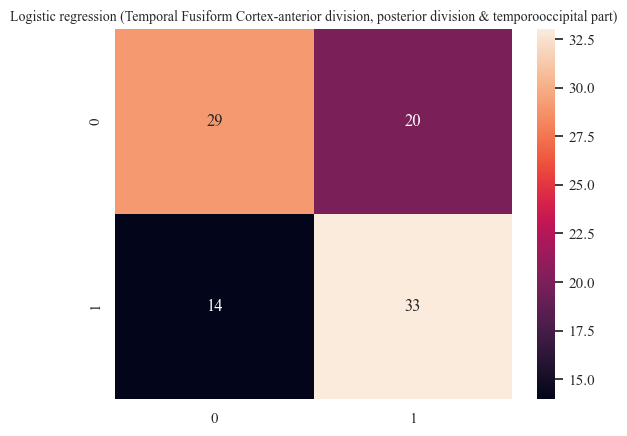

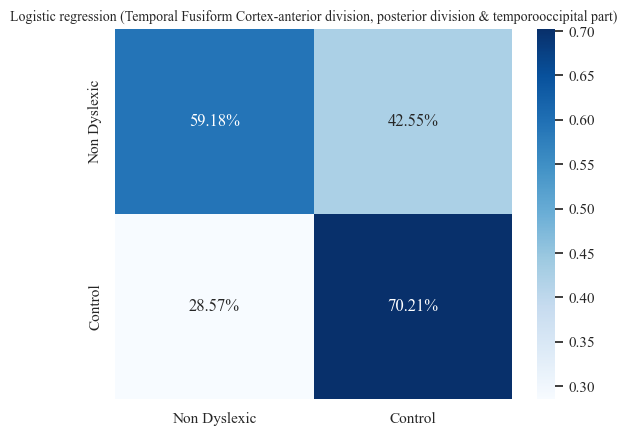

In [40]:
#Logistic regression
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine): 67.45%
Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part(Support Vector Machine): 52.08%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.52      0.82      0.63        49
           1       0.53      0.21      0.30        47

    accuracy                           0.52        96
   macro avg       0.52      0.51      0.47        96
weighted avg       0.52      0.52      0.47        96


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine): 0.51


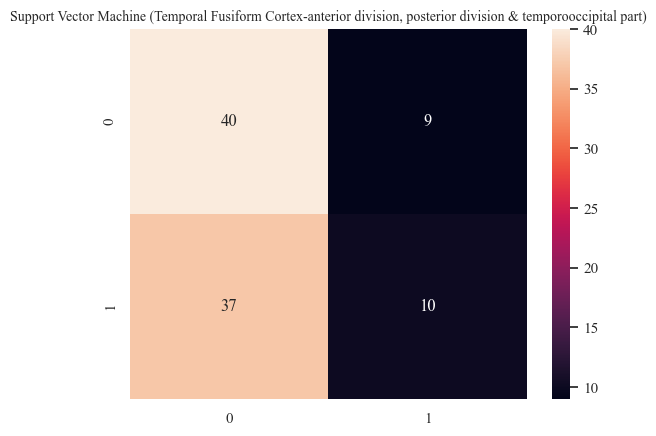

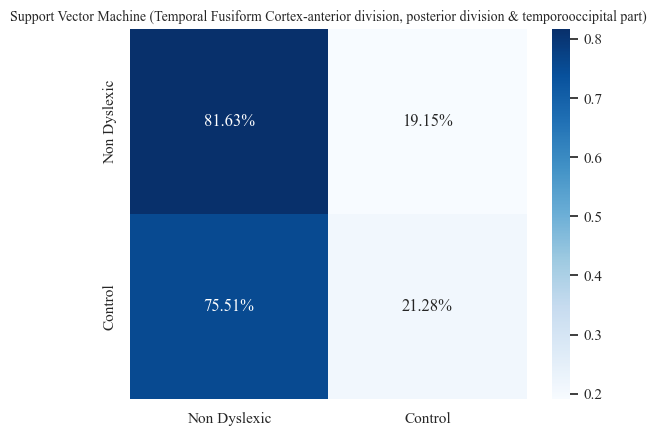

In [41]:
#Support Vector Machine
# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part(Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 73.96%
Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 53.12%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.58      0.31      0.40        49
           1       0.51      0.77      0.62        47

    accuracy                           0.53        96
   macro avg       0.55      0.54      0.51        96
weighted avg       0.55      0.53      0.51        96


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): 0.54


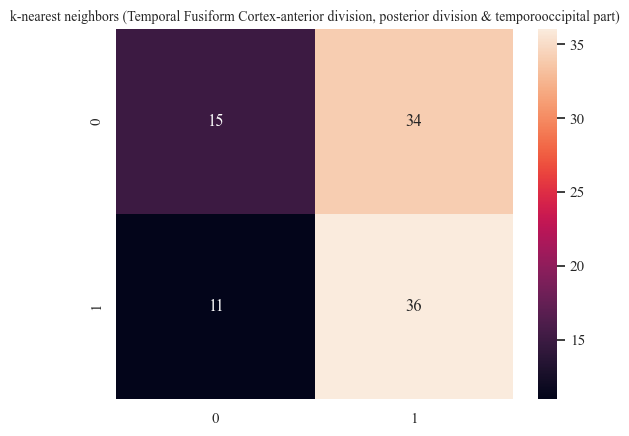

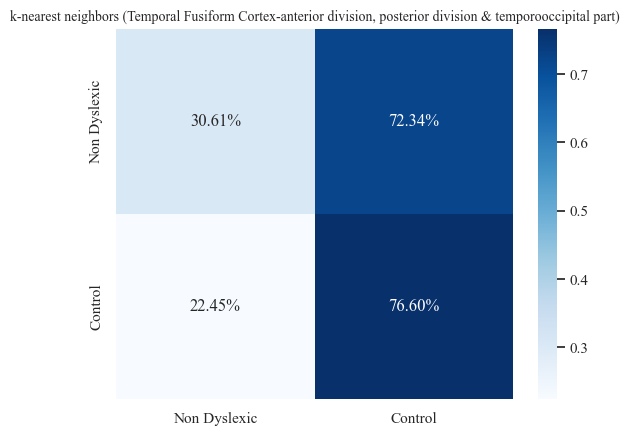

In [42]:
# k-nearest neighbors

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(KNN)_percent.png", dpi=600)
plt.show()

In [43]:
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (480, 5553)
Total Labels:-  (480,)
Total Training set:-  Dataset:- (384, 5553) Label:- (384,)
Total Testing set:-  Dataset:- (96, 5553) Label:- (96,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 512)                 │       2,843,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,919,681 (11.14 MB)

 Trainable params: 2,919,681 (11.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5134 - loss: 0.7597
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6087 - loss: 0.6405
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6235 - loss: 0.6372
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6647 - loss: 0.5703
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7355 - loss: 0.6132
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7493 - loss: 0.4514
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7921 - loss: 0.4677
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8147 - loss: 0.4223
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8177 - loss: 0.3881
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8392 - loss: 0.3619
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9178 - loss: 0.2883
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8776 - loss: 0.2638
E

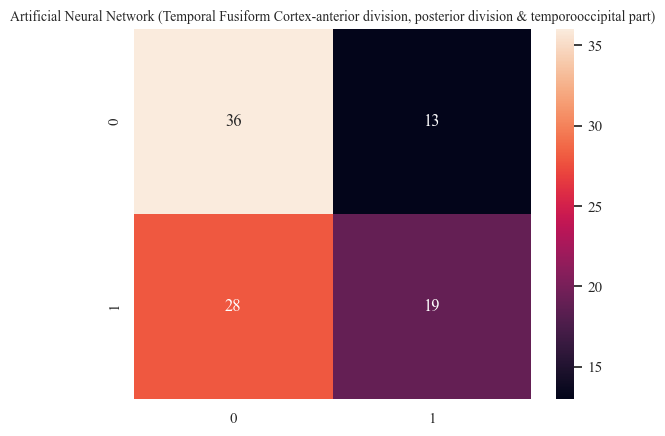

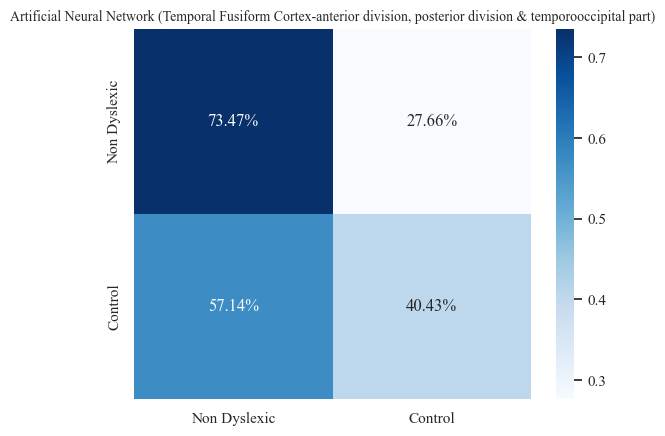

In [44]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(ANN)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): 100.00%
Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): 53.12%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest):
              precision    recall  f1-score   support

           0       0.54      0.57      0.55        49
           1       0.52      0.49      0.51        47

    accuracy                           0.53        96
   macro avg       0.53      0.53      0.53        96
weighted avg       0.53      0.53      0.53        96


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): 0.53


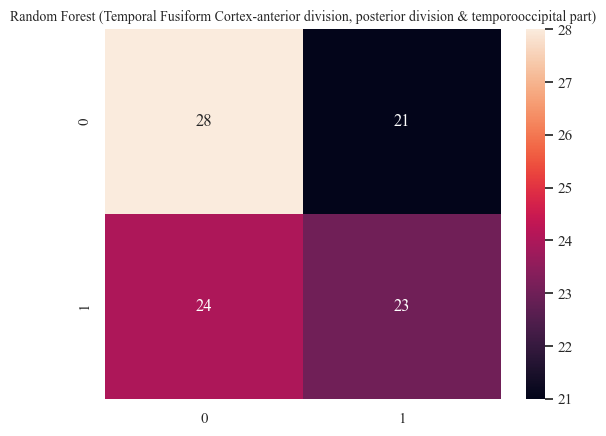

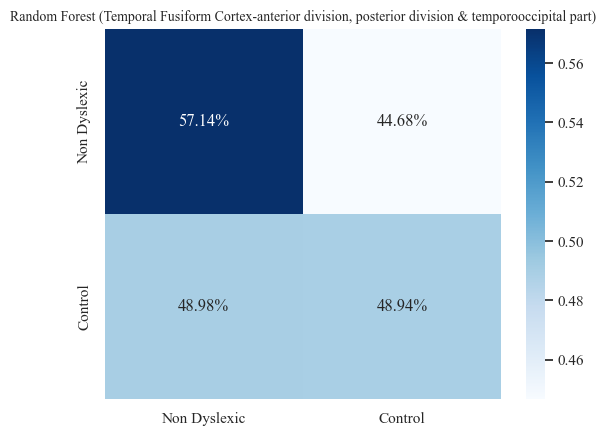

In [45]:
# Random Forest Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(Rand_Frst)_simple.png", dpi=600)
plt.show() 
plt.title('Random Forest (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(Rand_Frst)_percent.png", dpi=600)
plt.show()

Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): 100.00%
Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): 52.08%

Classification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost):
              precision    recall  f1-score   support

           0       0.53      0.61      0.57        49
           1       0.51      0.43      0.47        47

    accuracy                           0.52        96
   macro avg       0.52      0.52      0.52        96
weighted avg       0.52      0.52      0.52        96


ROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): 0.52


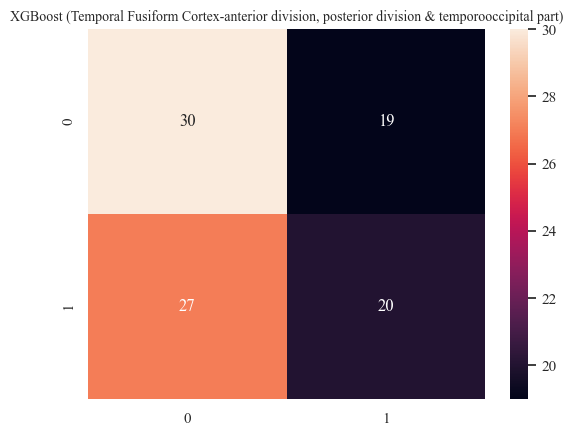

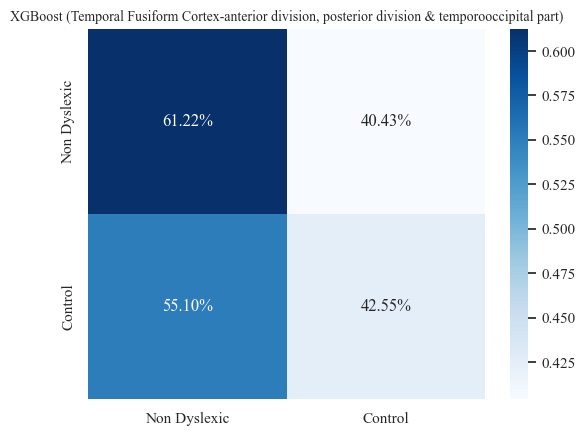

In [46]:
# XGBoost (Extreme Gradient Boosting) Model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data on Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part (XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(XGBst)_simple.png", dpi=600)
plt.show() 
plt.title('XGBoost (Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Temporal_Fusiform_Cortex_All_ROIs(XGBst)_percent.png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [47]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Control']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table: Temporal Fusiform Cortex-anterior division, posterior division & temporooccipital part [All ROIs (Mean)]")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/7-Temporal_Fusiform_Cortex/Output_Mean/Table_Mean_All_ROIs_Temporal_Fusiform_Cortex.xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.67    0.59      0.63     0.65   
                           Control            0.62    0.70      0.66            
Support Vector Machine     Non-Dyslexic       0.52    0.82      0.63     0.52   
                           Control            0.53    0.21      0.30            
k-nearest neighbors        Non-Dyslexic       0.58    0.31      0.40     0.53   
                           Control            0.51    0.77      0.62            
Artificial Neural Networks Non-Dyslexic       0.56    0.73      0.64     0.57   
                           Control            0.59    0.40      0.48            
Random Forest              Non-Dyslexic       0.54    0.57      0.55     0.53   
                           Control            0.52    0.49      0.51            
XGBoost                    Non-Dyslexic       0.53    0.61      0.57     0.52   
                           Control            0.51    0.43      0.47            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.65  
                           Control               
Support Vector Machine     Non-Dyslexic    0.51  
                           Control               
k-nearest neighbors        Non-Dyslexic    0.54  
                           Control               
Artificial Neural Networks Non-Dyslexic    0.57  
                           Control               
Random Forest              Non-Dyslexic    0.53  
                           Control               
XGBoost                    Non-Dyslexic    0.52  
                           Control